# Live SPUR performance sample

This notebook evaluates the existing **`spur` PID 71291**, started 2026-10-09 at 10:15:28 local time. It records a warm, observational snapshot of the current session: 10 seconds before profiling, three requested 10-second macOS `sample` captures at 5 ms intervals, and 10 seconds after profiling. No synthetic workload is injected.

CPU comes from **cumulative process user/system CPU counters**, measured against monotonic elapsed time; 100% means one logical CPU. Memory uses RSS and the macOS physical-footprint counter. Child processes are excluded. Stack samples include sleeping threads, so their percentages represent **thread observations**, not CPU percentages or user-request latency. Sample command time includes setup and symbolication.

The solver verifies explicitly encoded resource envelopes using catalog `resource` rules. Physical host capacity and illustrative budgets are separate scenarios; no latency or production SLO is assumed. The capture is not a benchmark of cold startup, throughput, or worst-case behavior.

Raw artifacts and capture source: `deliveries/spur-performance-71291-20261009/`. Run the code cells from top to bottom to reproduce the analysis from saved files.

**CPU units validated:** `proc_pid_rusage` CPU counters on this host use Mach ticks. Conversion is `ticks × 125 / 3 / 1e9` seconds, using the host timebase. Converted cumulative user/system time agreed with `ps` within 0.005 seconds; the saved validation is `cpu-unit-validation.json`. Apple’s [XNU rusage implementation](https://github.com/apple-oss-distributions/xnu/blob/main/osfmk/kern/bsd_kern.c#L1187) assigns these counters from task power accounting. Raw counter values are preserved in the CSV.

## Findings

| Measurement | Observed value |
|---|---:|
| Capture window | 2026-10-09 10:21:42–10:22:35, UTC+07 |
| Elapsed observation | 53.15 s |
| Process CPU | 17.01 s user + 3.55 s system |
| Average CPU | 38.69% of one logical CPU; 4.84% of 8-core nominal capacity |
| Peak approximately 1-second CPU interval | 101.70% of one logical CPU |
| RSS | 1185.78 → 1185.89 MiB; **+0.109 MiB** |
| Peak physical footprint | 1108.78 MiB |
| Disk I/O counter deltas | 32 KiB read; 640 KiB written |
| Page-ins | 0 |
| Interrupt wakeups | 4752 over the window |
| Stack captures | 3 × requested 10 s; 36 threads; 184,716 thread observations |

The process alternates between low activity and bursts near one CPU. Baseline average CPU was **43.25%**; the three profiler command windows averaged **36.53%, 2.94%, and 41.17%**; recovery averaged **73.29%**. These are different periods of normal session activity, not controlled repetitions. They do not isolate profiler overhead. The three sampler processes themselves used **2.10 CPU seconds** in total (including symbolication), accounted separately from the target.

Of 1,641 observations outside the explicitly recognized wait primitives, **1,415 (86.23%)** had `spur_pm::beads_crate::beads_db::reader_loop` on the stack; **1,170 (71.30%)** had `spur_pm::graph_engine::snapshot::load_graph_snapshot`. Nested paths included issue listing, dependency/label reads, and snapshot hashing. TUI `App::render` appeared in **32 (1.95%)**. These inclusive percentages overlap and are not CPU-time percentages.

**First follow-up target:** measure graph-snapshot refresh frequency and its callers during the same user workload. The profile supports investigating repeated snapshot/database work; it does not establish that a particular cache or lock change is safe or beneficial.

**Memory:** RSS was stable over this short window. That is evidence against rapid growth during the capture, not a leak test or an allocation breakdown.

**Solver:** the observed envelope, rounded up to **1018 millicores / 1186 MiB**, passes the physical 8-CPU / 16-GiB host-capacity scenario and the illustrative 2-CPU / 1.5-GiB budget. It fails the illustrative 1-CPU / 1-GiB budget on both resources. Host capacity is a total, not measured free capacity.

**Limits:** this is one warm session, including ordinary assistant/tool activity; no quiescent-idle or fixed-workload guarantee. No latency, throughput, child-process cost, allocation ownership, or long-run memory behavior was measured. Known waits account for **99.11% of all thread observations**, a denominator dominated by many parked threads; this does not mean the whole application is idle or blocked 99% of wall time. Actual per-thread sample counts were 1661, 1737 and 1733; the requested 5 ms interval is not a guarantee of achieved rate.


In [9]:
from pathlib import Path
import csv, json, math, statistics, re, hashlib
from collections import Counter, defaultdict
from IPython.display import display, Markdown, HTML
ROOT = Path("/Volumes/Projects/spur/deliveries/spur-performance-71291-20261009")
meta = json.loads((ROOT / "capture.json").read_text())
SECONDS_PER_TICK = meta["timebase"]["numer"] / meta["timebase"]["denom"] / 1e9
unit_check = json.loads((ROOT / "cpu-unit-validation.json").read_text())
assert max(unit_check["absolute_differences_s"]) < unit_check["tolerance_s"]
with (ROOT / "telemetry.csv").open() as f:
    raw = list(csv.DictReader(f))
rows = [{k: (v if k in ("utc", "phase") else float(v) if k == "elapsed_s" else int(v)) for k,v in r.items()} for r in raw]
assert len({r["proc_start_abstime"] for r in rows}) == 1, "PID changed"
intervals = []
for a,b in zip(rows, rows[1:]):
    dt_s = b["elapsed_s"]-a["elapsed_s"]
    if a["phase"] != b["phase"] or dt_s < 0.5:
        continue
    u = (b["user_time"]-a["user_time"])*SECONDS_PER_TICK
    s = (b["system_time"]-a["system_time"])*SECONDS_PER_TICK
    assert min(u,s) >= 0
    intervals.append(dict(phase=b["phase"], elapsed_s=b["elapsed_s"], dt_s=dt_s,
                          user_s=u, system_s=s, cpu_pct=100*(u+s)/dt_s,
                          rss_mib=b["resident_size"]/2**20,
                          footprint_mib=b["phys_footprint"]/2**20))
phase_stats=[]
for phase in dict.fromkeys(r["phase"] for r in rows):
    values=[x for x in intervals if x["phase"]==phase]
    phase_rows=[x for x in rows if x["phase"]==phase]
    wall=sum(x["dt_s"] for x in values)
    phase_stats.append(dict(phase=phase, wall_s=wall,
        user_s=sum(x["user_s"] for x in values), system_s=sum(x["system_s"] for x in values),
        avg_cpu_pct=100*sum(x["user_s"]+x["system_s"] for x in values)/wall,
        max_interval_cpu_pct=max(x["cpu_pct"] for x in values),
        rss_start_mib=phase_rows[0]["resident_size"]/2**20,
        rss_end_mib=phase_rows[-1]["resident_size"]/2**20))
wall=rows[-1]["elapsed_s"]-rows[0]["elapsed_s"]
user_s=(rows[-1]["user_time"]-rows[0]["user_time"])*SECONDS_PER_TICK
system_s=(rows[-1]["system_time"]-rows[0]["system_time"])*SECONDS_PER_TICK
summary=dict(pid=meta["pid"],wall_s=wall,user_s=user_s,system_s=system_s,
    avg_cpu_pct=100*(user_s+system_s)/wall,
    peak_interval_cpu_pct=max(x["cpu_pct"] for x in intervals),
    rss_start_mib=rows[0]["resident_size"]/2**20,
    rss_end_mib=rows[-1]["resident_size"]/2**20,
    peak_rss_mib=max(r["resident_size"] for r in rows)/2**20,
    peak_footprint_mib=max(r["phys_footprint"] for r in rows)/2**20,
    pageins_delta=rows[-1]["pageins"]-rows[0]["pageins"],
    disk_read_bytes=rows[-1]["diskio_bytesread"]-rows[0]["diskio_bytesread"],
    disk_write_bytes=rows[-1]["diskio_byteswritten"]-rows[0]["diskio_byteswritten"],
    interrupt_wakeups_delta=rows[-1]["interrupt_wkups"]-rows[0]["interrupt_wkups"],
    logical_cpus=meta["logical_cpus"],physical_memory_bytes=meta["physical_memory_bytes"],
    telemetry_rows=len(rows),valid_intervals=len(intervals),phase_stats=phase_stats)
(ROOT/"metrics.json").write_text(json.dumps(summary,indent=2))
display(Markdown("### Measured CPU and memory"))
table=["| Phase | Seconds | CPU avg % | CPU peak interval % | RSS end MiB |","|---|---:|---:|---:|---:|"]
for p in phase_stats:
    table.append(f'| {p["phase"]} | {p["wall_s"]:.2f} | {p["avg_cpu_pct"]:.2f} | {p["max_interval_cpu_pct"]:.2f} | {p["rss_end_mib"]:.3f} |')
display(Markdown("\n".join(table)))
print(f'Overall: {wall:.2f} s elapsed, {user_s:.3f} user CPU s, {system_s:.3f} system CPU s; {summary["avg_cpu_pct"]:.2f}% average CPU.')
print(f'CPU tick conversion checked against ps; maximum discrepancy {max(unit_check["absolute_differences_s"]):.6f} s.')
print("Full metrics saved to metrics.json.")


### Measured CPU and memory

| Phase | Seconds | CPU avg % | CPU peak interval % | RSS end MiB |
|---|---:|---:|---:|---:|
| baseline | 10.00 | 43.25 | 101.57 | 1185.797 |
| sample_1 | 11.05 | 36.53 | 98.82 | 1185.812 |
| sample_2 | 11.05 | 2.94 | 3.44 | 1185.812 |
| sample_3 | 11.03 | 41.17 | 99.07 | 1185.828 |
| recovery | 10.01 | 73.29 | 101.70 | 1185.891 |

Overall: 53.15 s elapsed, 17.013 user CPU s, 3.548 system CPU s; 38.69% average CPU.
CPU tick conversion checked against ps; maximum discrepancy 0.004334 s.
Full metrics saved to metrics.json.


In [10]:
def parse_sample(path):
    text = path.read_text()
    graph = text.split("Call graph:\n",1)[1].split("\nTotal number in stack",1)[0]
    nodes, stack = [], []
    for line in graph.splitlines():
        m = re.match(r"^([ +!:|]*)(\d+) (.+)$",line)
        if not m:
            assert not line.strip(), f"Unparsed graph line: {line!r}"
            continue
        depth, count, name = m.start(2), int(m[2]), m[3]
        while stack and nodes[stack[-1]]["depth"] >= depth:
            stack.pop()
        parent = stack[-1] if stack else None
        node = dict(depth=depth,count=count,name=name,parent=parent,children=[])
        if parent is not None:
            nodes[parent]["children"].append(len(nodes))
        nodes.append(node)
        stack.append(len(nodes)-1)
    roots=[i for i,n in enumerate(nodes) if n["parent"] is None]
    assert all("Thread_" in nodes[i]["name"] for i in roots)
    leaves=[]
    for i,n in enumerate(nodes):
        remainder=n["count"]-sum(nodes[c]["count"] for c in n["children"])
        assert remainder>=0, (path.name,n["name"],remainder)
        if remainder:
            ancestors=[]; current=i
            while current is not None:
                ancestors.append(nodes[current]["name"]); current=nodes[current]["parent"]
            ancestors.reverse()
            leaves.append(dict(sample=path.stem,thread=ancestors[0],count=remainder,frames=ancestors[1:]))
    total=sum(nodes[i]["count"] for i in roots)
    assert sum(x["count"] for x in leaves)==total
    return nodes,roots,leaves,total

def symbol(frame):
    return re.sub(r"::h[0-9a-f]{16}$","",frame.split("  (in ",1)[0])

def category(leaf):
    name=symbol(leaf["frames"][-1]) if leaf["frames"] else ""
    if name.startswith(("__psynch_cvwait","semaphore_wait_trap","semaphore_timedwait_trap","__ulock_wait")):
        return "Condition / semaphore wait"
    if name.startswith("__psynch_mutexwait"):
        return "Mutex wait"
    if name in ("kevent","kevent64","__select","select","poll","__poll","__workq_kernreturn"):
        return "Event / I/O wait"
    if name.startswith(("mach_msg","__semwait_signal","__psynch_rw","__nanosleep")):
        return "Other known wait"
    return "Other / unclassified"

all_leaves=[]; sample_stats=[]; per_thread=[]
for path in sorted(ROOT.glob("sample_*.txt")):
    nodes,roots,leaves,total=parse_sample(path)
    counts=Counter()
    for leaf in leaves:
        leaf["category"]=category(leaf); counts[leaf["category"]]+=leaf["count"]
    all_leaves.extend(leaves)
    sample_stats.append(dict(sample=path.stem,thread_count=len(roots),
        observations_per_thread_min=min(nodes[i]["count"] for i in roots),
        observations_per_thread_max=max(nodes[i]["count"] for i in roots),
        total_thread_observations=total,known_wait_pct=100*(total-counts["Other / unclassified"])/total,
        unclassified_observations=counts["Other / unclassified"],categories=dict(counts)))
    for root in roots:
        thread=nodes[root]["name"]
        mine=[x for x in leaves if x["thread"]==thread]
        other=sum(x["count"] for x in mine if x["category"]=="Other / unclassified")
        per_thread.append(dict(sample=path.stem,thread=thread,observations=nodes[root]["count"],
                               other_observations=other,other_pct=100*other/nodes[root]["count"]))
inclusive=Counter(); inclusive_other=Counter(); leaf_counts=Counter()
for leaf in all_leaves:
    leaf_counts[symbol(leaf["frames"][-1])]+=leaf["count"]
    for name in set(map(symbol,leaf["frames"])):
        inclusive[name]+=leaf["count"]
        if leaf["category"]=="Other / unclassified":
            inclusive_other[name]+=leaf["count"]
application=[dict(symbol=name,all_thread_observations=count,
                  other_observations=inclusive_other[name])
             for name,count in inclusive.items()
             if any(term in name for term in ("spur_pm::","beads_rust::","spur_tui::"))]
application.sort(key=lambda x:x["other_observations"],reverse=True)
stacks=dict(samples=sample_stats,total_thread_observations=sum(s["total_thread_observations"] for s in sample_stats),
            other_observations=sum(s["unclassified_observations"] for s in sample_stats),
            application_inclusive=application[:30],
            busiest_threads=sorted(per_thread,key=lambda x:x["other_observations"],reverse=True)[:15])
(ROOT/"stacks.json").write_text(json.dumps(stacks,indent=2))
for name,data in (("threads",per_thread),("application_frames",application)):
    with (ROOT/f"{name}.csv").open("w",newline="") as f:
        w=csv.DictWriter(f,fieldnames=list(data[0]));w.writeheader();w.writerows(data)
display(Markdown("### Stack occupancy — includes sleeping threads"))
table=["| Sample | Threads | Observations / thread | Total observations | Known waits % | Other observations |","|---|---:|---:|---:|---:|---:|"]
for s in sample_stats:
    table.append(f'| {s["sample"]} | {s["thread_count"]} | {s["observations_per_thread_min"]} | {s["total_thread_observations"]} | {s["known_wait_pct"]:.3f} | {s["unclassified_observations"]} |')
display(Markdown("\n".join(table)))
table=["| Inclusive application frame | Other observations | Share of other % |","|---|---:|---:|"]
for s in application[:12]:
    table.append(f'| {s["symbol"]} | {s["other_observations"]} | {100*s["other_observations"]/stacks["other_observations"]:.2f} |')
display(Markdown("\n".join(table)))
print("All tree counts conserved; no negative exclusive counts. Full stacks.json, threads.csv and application_frames.csv saved.")


### Stack occupancy — includes sleeping threads

| Sample | Threads | Observations / thread | Total observations | Known waits % | Other observations |
|---|---:|---:|---:|---:|---:|
| sample_1 | 36 | 1661 | 59796 | 98.764 | 739 |
| sample_2 | 36 | 1737 | 62532 | 99.872 | 80 |
| sample_3 | 36 | 1733 | 62388 | 98.682 | 822 |

| Inclusive application frame | Other observations | Share of other % |
|---|---:|---:|
| spur_pm::beads_crate::beads_db::reader_loop | 1415 | 86.23 |
| spur_pm::graph_engine::snapshot::load_graph_snapshot | 1170 | 71.30 |
| beads_rust::storage::sqlite::SqliteStorage::list_issues | 543 | 33.09 |
| spur_pm::beads_crate::dependency_compat::get_dependencies_full_for_issues | 233 | 14.20 |
| beads_rust::storage::sqlite::SqliteStorage::get_all_dependency_records | 223 | 13.59 |
| beads_rust::storage::sqlite::SqliteStorage::get_labels_for_issues | 216 | 13.16 |
| spur_pm::graph_engine::snapshot::GraphSnapshot::compute_data_hash | 187 | 11.40 |
| beads_rust::storage::sqlite::SqliteStorage::issue_from_row | 157 | 9.57 |
| beads_rust::util::hash::content_hash | 107 | 6.52 |
| beads_rust::util::hash::content_hash_from_parts | 105 | 6.40 |
| beads_rust::util::hash::HashFieldWriter::field | 99 | 6.03 |
| spur_tui::app::App::render | 32 | 1.95 |

All tree counts conserved; no negative exclusive counts. Full stacks.json, threads.csv and application_frames.csv saved.


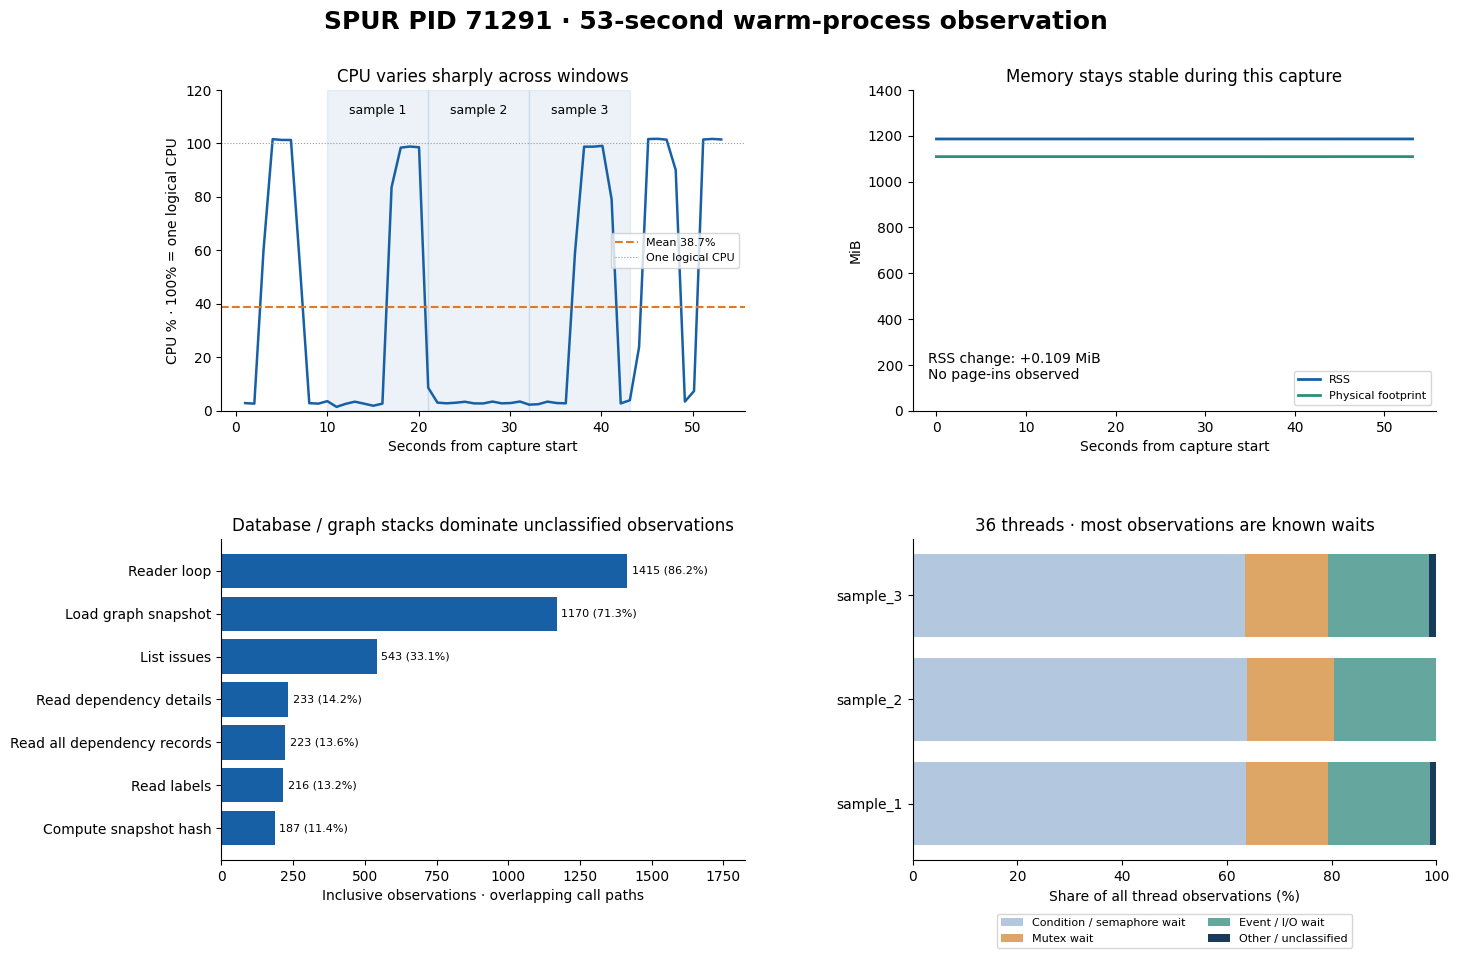

Shading marks sample **command** windows, including symbolication. Stack observations include sleeping threads. The unclassified category may include I/O or unrecognized waits; it is **not a CPU-time measurement**. Inclusive frame counts overlap and must not be summed.

In [12]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":10,"axes.spines.top":False,"axes.spines.right":False})
fig, ax=plt.subplots(2,2,figsize=(15,10))
fig.subplots_adjust(left=0.17,right=0.98,bottom=0.13,top=0.90,wspace=0.32,hspace=0.40)
fig.suptitle("SPUR PID 71291 · 53-second warm-process observation",fontsize=18,fontweight="bold")
t=[x["elapsed_s"] for x in intervals]
ax[0,0].plot(t,[x["cpu_pct"] for x in intervals],color="#1760a5",lw=1.8)
ax[0,0].axhline(summary["avg_cpu_pct"],color="#e07826",ls="--",label=f'Mean {summary["avg_cpu_pct"]:.1f}%')
ax[0,0].axhline(100,color="#999999",lw=0.8,ls=":",label="One logical CPU")
for window in meta["windows"]:
    ax[0,0].axvspan(window["command_start_s"],window["command_end_s"],color="#1760a5",alpha=0.08)
    ax[0,0].text((window["command_start_s"]+window["command_end_s"])/2,111,window["phase"].replace("_"," "),ha="center",fontsize=9)
ax[0,0].set(title="CPU varies sharply across windows",xlabel="Seconds from capture start",ylabel="CPU % · 100% = one logical CPU",ylim=(0,120))
ax[0,0].legend(loc="center right",fontsize=8)
ax[0,1].plot([r["elapsed_s"] for r in rows],[r["resident_size"]/2**20 for r in rows],label="RSS",color="#1760a5",lw=2)
ax[0,1].plot([r["elapsed_s"] for r in rows],[r["phys_footprint"]/2**20 for r in rows],label="Physical footprint",color="#2a9178",lw=2)
ax[0,1].set(title="Memory stays stable during this capture",xlabel="Seconds from capture start",ylabel="MiB",ylim=(0,1400))
ax[0,1].text(0.03,0.1,f'RSS change: {summary["rss_end_mib"]-summary["rss_start_mib"]:+.3f} MiB\nNo page-ins observed',transform=ax[0,1].transAxes)
ax[0,1].legend(loc="lower right",fontsize=8)
top=application[:7][::-1]
short_names=["Compute snapshot hash","Read labels","Read all dependency records","Read dependency details","List issues","Load graph snapshot","Reader loop"]
ax[1,0].barh(short_names,[x["other_observations"] for x in top],color="#1760a5")
ax[1,0].set(title="Database / graph stacks dominate unclassified observations",xlabel="Inclusive observations · overlapping call paths")
for i,x in enumerate(top):
    ax[1,0].text(x["other_observations"]+15,i,f'{x["other_observations"]} ({100*x["other_observations"]/stacks["other_observations"]:.1f}%)',va="center",fontsize=8)
ax[1,0].set_xlim(0,max(x["other_observations"] for x in top)*1.29)
colors={"Condition / semaphore wait":"#b3c8df","Mutex wait":"#dda566","Event / I/O wait":"#65a79f","Other / unclassified":"#183a5b"}
left=[0]*len(sample_stats)
for cat,color in colors.items():
    vals=[100*s["categories"].get(cat,0)/s["total_thread_observations"] for s in sample_stats]
    ax[1,1].barh([s["sample"] for s in sample_stats],vals,left=left,color=color,label=cat)
    left=[a+b for a,b in zip(left,vals)]
ax[1,1].set(title="36 threads · most observations are known waits",xlabel="Share of all thread observations (%)",xlim=(0,100))
ax[1,1].legend(loc="upper center",bbox_to_anchor=(0.5,-0.15),fontsize=8,ncol=2)
fig.savefig(ROOT/"performance.png",dpi=150)
fig.savefig(ROOT/"performance.svg")
plt.show()
display(Markdown("Shading marks sample **command** windows, including symbolication. Stack observations include sleeping threads. The unclassified category may include I/O or unrecognized waits; it is **not a CPU-time measurement**. Inclusive frame counts overlap and must not be summed."))


In [7]:
solve_artifacts=[json.loads(p.read_text()) for p in sorted(ROOT.glob("*.solve.json"))]
expected={"cpu":math.ceil(summary["peak_interval_cpu_pct"]*10),"memory":math.ceil(summary["peak_rss_mib"])}
table=["| Scenario | CPU budget | Memory budget | CPU / memory | Solver status | Solve ID |","|---|---:|---:|---|---|---|"]
for item in solve_artifacts:
    req,res=item["request"],item["response"]
    assert req["facts"]["workloads"]["spur"]["requests"]==expected, "Stale solve input: re-run solve_rules"
    assert req["mode"]=="verify" and res["mode"]=="verify"
    limits=req["facts"]["workloads"]["spur"]["limits"]
    table.append(f'| {item["scenario"]} | {limits["cpu"]/1000:g} cores | {limits["memory"]} MiB | '+ " / ".join(r["outcome"] for r in res["rule_results"])+f' | {res["status"]} · {res["outcome"]} | {res["solve_id"]} |')
display(Markdown("### Catalog solver verification\n\nMeasured envelope, rounded up: **"+str(expected["cpu"])+" millicores, "+str(expected["memory"])+" MiB RSS**. Each resource has its own rule binding.\n\n"+"\n".join(table)))
display(Markdown("Catalog rules: `resource.aggregate_capacity` checks the host scenario; `resource.request_within_limit` checks the two illustrative budgets. **verify + sat/pass** accepts the encoded sample; **verify + unsat/fail** rejects it. The 1-core / 1-GiB example fails both bindings. These are descriptive checks of captured peaks, not recommended limits, future guarantees, an optimal allocation, or a latency verdict. Host totals exclude other processes and the operating system. Independently rounded CPU/RSS peaks need not occur together."))
print("Exact requests, units, flattened responses and solve IDs are saved in *.solve.json.")


### Catalog solver verification

Measured envelope, rounded up: **1018 millicores, 1186 MiB RSS**. Each resource has its own rule binding.

| Scenario | CPU budget | Memory budget | CPU / memory | Solver status | Solve ID |
|---|---:|---:|---|---|---|
| example_1_cpu_1_gib | 1 cores | 1024 MiB | fail / fail | unsat · fail | sol_0966edcc7e4c4a69 |
| example_2_cpu_1_5_gib | 2 cores | 1536 MiB | pass / pass | sat · pass | sol_727d7cdaa2ae497e |
| physical_host_capacity | 8 cores | 16384 MiB | pass / pass | sat · pass | sol_35301e4746074ada |

Catalog rules: `resource.aggregate_capacity` checks the host scenario; `resource.request_within_limit` checks the two illustrative budgets. **verify + sat/pass** accepts the encoded sample; **verify + unsat/fail** rejects it. The 1-core / 1-GiB example fails both bindings. These are descriptive checks of captured peaks, not recommended limits, future guarantees, an optimal allocation, or a latency verdict. Host totals exclude other processes and the operating system. Independently rounded CPU/RSS peaks need not occur together.

Exact requests, units, flattened responses and solve IDs are saved in *.solve.json.


In [13]:
# Independent checks against macOS sample's own collapsed leaf summary.
checked = 0
for p in sorted(ROOT.glob("sample_*.txt")):
    block=p.read_text().split("Sort by top of stack, same collapsed (when >= 5):",1)[1].split("Binary Images:",1)[0]
    counts=Counter()
    for leaf in all_leaves:
        if leaf["sample"]==p.stem:
            counts[symbol(leaf["frames"][-1])]+=leaf["count"]
    for line in block.splitlines():
        m=re.match(r"^\s+(.+?)\s+\(in .+?\)\s+(\d+)\s*$",line)
        if m and m[1] in ("__psynch_cvwait","__psynch_mutexwait","kevent","semaphore_wait_trap","semaphore_timedwait_trap"):
            assert counts[m[1]]==int(m[2]), (p.name,m[1],counts[m[1]],m[2])
            checked+=1
assert checked >= 12
assert sum(s["total_thread_observations"] for s in sample_stats)==184716
assert all(w["returncode"]==0 for w in meta["windows"])
assert all(p.exists() and p.stat().st_size>0 for p in (ROOT/"performance.png",ROOT/"performance.svg"))
assert len(solve_artifacts)==3
assert {(x["scenario"],x["response"]["status"],x["response"]["outcome"]) for x in solve_artifacts} == {
    ("physical_host_capacity","sat","pass"),
    ("example_1_cpu_1_gib","unsat","fail"),
    ("example_2_cpu_1_5_gib","sat","pass")}
manifest = {p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(ROOT.iterdir())
            if p.is_file() and p.name not in ("sha256.json","verification.json")}
(ROOT/"sha256.json").write_text(json.dumps(manifest,indent=2))
verification={"sample_summary_checks":checked,"stack_observation_count":stacks["total_thread_observations"],
              "cpu_counter_ps_error_s":max(unit_check["absolute_differences_s"]),
              "solver_cases":len(solve_artifacts),"artifact_hashes":len(manifest),"status":"passed"}
(ROOT/"verification.json").write_text(json.dumps(verification,indent=2))
display(Markdown("### Verification\n\nCPU units cross-checked with ps; all stack counts conserve observations; recognized-wait totals agree with macOS sample’s independent collapsed summary; solver requests match the computed envelope; plots exist. Raw data and result hashes saved to sha256.json."))
print(json.dumps(verification,indent=2))


### Verification

CPU units cross-checked with ps; all stack counts conserve observations; recognized-wait totals agree with macOS sample’s independent collapsed summary; solver requests match the computed envelope; plots exist. Raw data and result hashes saved to sha256.json.

{
  "sample_summary_checks": 15,
  "stack_observation_count": 184716,
  "cpu_counter_ps_error_s": 0.004333625000001007,
  "solver_cases": 3,
  "artifact_hashes": 21,
  "status": "passed"
}
